In [1]:
from rpgpy import rpg2nc
import numpy as np
from gfatpy.radar.rpg_nc import rpg
import os
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import glob
from gfatpy.radar.retrieve.retrieve import (
    retrieve_dBZe,
)
%matplotlib inline

In [2]:
# filepath for bucharest data
l1_filepath = "/Users/matheussilva/Documents/dealiasing/data/output_matlab/bucharest/inoe94_rad_210601_120001_P06_ZEN.nc"

In [2]:
# filepath for granada data
radar_str = "nebula_w"
date_str = "2024/12/19"

product_folder = f"/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/{radar_str}/l1/{date_str}"
lv0_filepaths = sorted( glob.glob(os.path.join(product_folder, "*ZEN.nc")) )
lv0_filepaths

['/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_070028_P00_ZEN.nc',
 '/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_070535_P00_ZEN.nc',
 '/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_071043_P00_ZEN.nc',
 '/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_071551_P00_ZEN.nc',
 '/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_072059_P00_ZEN.nc',
 '/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_072607_P00_ZEN.nc',
 '/Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_073114_P00_ZEN.nc',
 '/Users/matheussilv

In [3]:
i=0
l1_filepath = lv0_filepaths[i]
print(f"Filepath: {l1_filepath}")

Filepath: /Users/matheussilva/Documents/dealiasing/data/output_matlab/granada/nebula_w/l1/2024/12/19/granada94_gra_BaseN_241219_070028_P00_ZEN.nc


In [4]:
# Read data with xarray
ds = xr.open_dataset(l1_filepath)
ds.head()

<xarray.Dataset>
Dimensions:                 (scalar: 1, number.chirp.sequences: 3, velocity: 5,
                             range: 5, T_range: 5, H_range: 5, time: 5)
Coordinates:
  * scalar                  (scalar) int32 1
  * number.chirp.sequences  (number.chirp.sequences) int32 1 2 3
  * velocity                (velocity) int32 1 2 3 4 5
  * range                   (range) float32 102.2 127.8 153.3 178.9 204.4
  * time                    (time) datetime64[ns] 2024-12-19T07:00:28 ... 202...
Dimensions without coordinates: T_range, H_range
Data variables: (12/81)
    lat                     (scalar) float32 ...
    lon                     (scalar) float32 ...
    zsl                     (scalar) float32 ...
    freq_sb                 (scalar) float32 ...
    wl                      (scalar) float32 ...
    hpbw                    (scalar) float32 ...
    ...                      ...
    sen_lim_vv              (time, range) float32 ...
    sze_hh                  (time, range, velocity) float32 ...
    scov_re                 (time, range, velocity) float32 ...
    scov_im                 (time, range, velocity) float32 ...
    h_noise_pow_mean        (time, range) float32 ...
    h_noise_pow_peak        (time, range) float32 ...
Attributes: (12/23)
    FillValue:         NaN
    program_name:      Doppler 3 sec
    PI_NAME:           Surname;Name
    PI_AFFILIATION:    Example University (UNI);State
    PI_ADDRESS:        Example University,Institute;Street;Postcode;City;State
    PI_MAIL:           pi.example@example-uni.com
    ...                ...
    DATA_LOCATION:     Research station XYZ;Country
    DATA_SOURCE:       Radar.Standard.Moments.Ldr_granada94;run by UNI
    DATA_PROCESSING:   https://github.com/igmk/w-radar/releases/tag/v2.0_202007
    FILL_VALUE:        NaN
    INSTRUMENT_MODEL:  94 GHz dual pol.
    MDF_PROGRAM_USED:  Doppler 3 sec

In [4]:
ds.velocity

<xarray.DataArray 'velocity' (velocity: 1024)>
array([   1,    2,    3, ..., 1022, 1023, 1024], dtype=int32)
Coordinates:
  * velocity  (velocity) int32 1 2 3 4 5 6 7 ... 1019 1020 1021 1022 1023 1024
Attributes:
    comment:  Variable for velocity-dimension

In [4]:
ds.AliasStatus

<xarray.DataArray 'AliasStatus' (time: 1195, range: 424)>
[506680 values with dtype=float32]
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    standard_name:  Flags indicating quality of dealiasing.
    comment:        Must be converted into four bit binary string. If 0, i.e....

In [5]:
ds.ze_hv

<xarray.DataArray 'ze_hv' (time: 1195, range: 424)>
[506680 values with dtype=float32]
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    GEOMS_name:     RADAR.REFLECTIVITY.FACTOR_HV
    long_name:      equivalent_reflectivity_factor
    rpg_name:       Ze_hv
    standard_name:  Equivalent radar reflectivity factor of the cross polariz...
    units:          mm6 m-3
    valid_range:    [4.99999986e-10 1.39954042e+00]
    fill_value:     NaN
    comment:        "Equivalent reflectivity factor" is the radar reflectivit...

In [23]:
ds['number.chirp.sequences'].values[-1].item()

3

In [30]:
print(f"Range offsets: {ds.range_offsets.values}")
print(f"DZ by chirp: {ds.dz_chirp.values}")
print(f"Doppler length: {ds.dopp_len.values}")
# print(f"Alias Status: {ds.AliasStatus.values}")

# Create a new variable named chirp mask, which is a boolean array that indicates the chirp number for each range gate
chirp_mask = np.ones(ds.range.shape[0])*ds['number.chirp.sequences'].values[-1].item()
for i, chirp_ in enumerate(ds['number.chirp.sequences'].values[:-1]):
    chirp_idx = np.arange(ds.range_offsets[i]-1, ds.range_offsets[i+1]-1, 1)
    print(f"Min: {chirp_idx[0]}, Max: {chirp_idx[-1]}")
    chirp_mask[chirp_idx] = chirp_

ds['chirp_mask'] = xr.DataArray(chirp_mask, dims='range')
    

Range offsets: [ 1 21 74]
DZ by chirp: [25.55309  26.499464 37.65671 ]
Doppler length: [512 512 512]
Min: 0, Max: 19
Min: 20, Max: 72


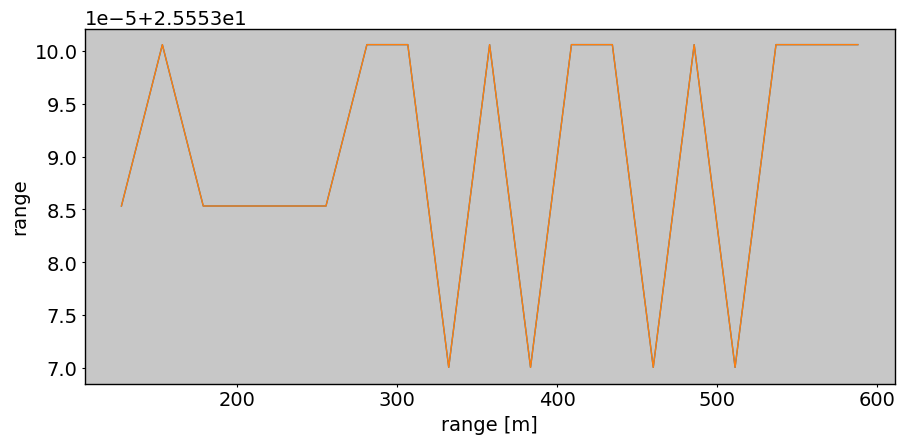

In [35]:
i=0
plt.figure(figsize=(10,5))
ds.sel(range=(chirp_mask==ds['number.chirp.sequences'][i].values.item())).range.diff('range').plot()

ds.isel(range=slice(ds.range_offsets[i].values-1, ds.range_offsets[i+1].values-1)).range.diff('range').plot()
# OBS: The range_offsets are close bracket in the lower bound and open bracket in the upper bound
plt.show()

In [8]:
ds["sze_dBZ"] = retrieve_dBZe(ds["sze"], "W")

chirp_info = {"range_limits": {}, "height_ratio": {}}
for i, chirp_ in enumerate(ds["number.chirp.sequences"].values):
    rs_ds = ds.sel(range=ds["chirp_mask"].values == chirp_)
    min_range = rs_ds.range.min().values.item()
    max_range = rs_ds.range.max().values.item()
    range_limits = [min_range, max_range]
    height_ratio = (max_range - min_range) / (ds.range.max().values.item() - ds.range.min().values.item())
    chirp_info["range_limits"][chirp_] = range_limits
    chirp_info["height_ratio"][chirp_] = height_ratio

In [31]:
ds.mask

<xarray.DataArray 'mask' (time: 1195, range: 424)>
[506680 values with dtype=int8]
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    standard_name:  Mask array of occupied range cells: 0 = not occupied; 1 =...
    comment:        Mask(time,range) is set to 0 when signal does not exceed ...

In [36]:
sds = ds.sel(range=ds["chirp_mask"].values == 1, time=target_time)

In [39]:
sds.chirp_vel.sel({"number.chirp.sequences": 1})

<xarray.DataArray 'chirp_vel' (velocity: 1024)>
[1024 values with dtype=float32]
Coordinates:
    number.chirp.sequences  int32 1
  * velocity                (velocity) int32 1 2 3 4 5 ... 1021 1022 1023 1024
    time                    datetime64[ns] 2021-06-01T12:04:59
Attributes:
    standard_name:  Velocity arrays for each chirp sequence
    units:          m/s
    comment:        If spectra has been dealiased, use MinVel to get the corr...

In [62]:
sds.MinVel

<xarray.DataArray 'MinVel' (range: 97)>
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
      dtype=float32)
Coordinates:
  * range    (range) float32 1.007e+04 1.012e+04 ... 1.492e+04 1.497e+04
    time     datetime64[ns] 2021-06-01T12:04:59
Attributes:
    standard_name:  Minimum velocity in velocity array
    comment:        If dealising was applied the array indicates the velocity...
    units:          m/s

In [74]:
ds.MinVel.sel(range=ds["chirp_mask"].values == 1)

<xarray.DataArray 'MinVel' (time: 1195, range: 37)>
array([[-12.115431, -12.626413, -12.593447, ..., -11.901148, -12.115431,
        -11.950598],
       [-12.016531, -12.016531, -12.445097, ..., -12.181364, -12.197847,
        -12.033014],
       [-11.785765, -11.785765, -13.005529, ..., -12.214331, -12.214331,
        -12.115431],
       ...,
       [-12.098948, -11.950598, -12.56048 , ..., -12.346197, -12.80773 ,
        -12.873663],
       [-11.983564, -12.082464, -12.445097, ..., -12.164881, -13.022013,
        -12.890146],
       [-12.41213 , -12.214331, -12.543997, ..., -12.60993 , -12.527514,
        -12.527514]], dtype=float32)
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.031e+03 1.058e+03 1.085e+03
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    standard_name:  Minimum velocity in velocity array
    comment:        If dealising was applied the array indicates the velocity...
    units:          m/s

In [76]:
vel_true = (ds.chirp_vel.sel({"number.chirp.sequences": 1}) - ds.chirp_vel.sel({"number.chirp.sequences": 1})[0]) + ds.MinVel.sel(range=ds["chirp_mask"].values == 1)

In [91]:
dop_vel.values.shape

(1024, 37)

In [106]:
dop_vel.range

<xarray.DataArray 'range' (range: 128)>
array([1126.5035, 1156.9496, 1187.3956, 1217.8417, 1248.2877, 1278.7338,
       1309.1798, 1339.6259, 1370.0719, 1400.518 , 1430.964 , 1461.41  ,
       1491.8561, 1522.3021, 1552.7482, 1583.1942, 1613.6403, 1644.0863,
       1674.5323, 1704.9784, 1735.4244, 1765.8705, 1796.3165, 1826.7626,
       1857.2086, 1887.6547, 1918.1007, 1948.5468, 1978.9928, 2009.4388,
       2039.8849, 2070.3308, 2100.7769, 2131.223 , 2161.669 , 2192.115 ,
       2222.561 , 2253.007 , 2283.4531, 2313.8992, 2344.3452, 2374.7913,
       2405.2373, 2435.6833, 2466.1294, 2496.5754, 2527.0215, 2557.4675,
       2587.9136, 2618.3596, 2648.8057, 2679.2517, 2709.6978, 2740.1438,
       2770.5898, 2801.036 , 2831.482 , 2861.928 , 2892.374 , 2922.82  ,
       2953.266 , 2983.7122, 3014.1582, 3044.6042, 3075.0503, 3105.4963,
       3135.9424, 3166.3884, 3196.8345, 3227.2805, 3257.7266, 3288.1726,
       3318.6187, 3349.0647, 3379.5107, 3409.9568, 3440.4028, 3470.8489,
       3501.295 , 3531.741 , 3562.187 , 3592.633 , 3623.079 , 3653.5251,
       3683.9712, 3714.4172, 3744.8633, 3775.3093, 3805.7554, 3836.2014,
       3866.6475, 3897.0935, 3927.5396, 3957.9856, 3988.4316, 4018.8777,
       4049.3237, 4079.7698, 4110.216 , 4140.6616, 4171.108 , 4201.5537,
       4232.    , 4262.446 , 4292.892 , 4323.338 , 4353.784 , 4384.23  ,
       4414.6763, 4445.122 , 4475.5684, 4506.014 , 4536.4604, 4566.9062,
       4597.3525, 4627.7983, 4658.2446, 4688.6904, 4719.1367, 4749.5825,
       4780.029 , 4810.4746, 4840.921 , 4871.3667, 4901.813 , 4932.259 ,
       4962.705 , 4993.151 ], dtype=float32)
Coordinates:
    number.chirp.sequences  int32 2
    time                    datetime64[ns] 2021-06-01T12:04:59
  * range                   (range) float32 1.127e+03 1.157e+03 ... 4.993e+03
Attributes:
    GEOMS_name:     RANGE
    long_name:      range
    rpg_name:       range
    standard_name:  Range gates of the radar measurements
    short_name:     range
    units:          m
    valid_range:    [  108.50956 14973.817  ]
    comment:        Range from the radar antenna to the center of the radar r...

In [118]:
dop_vel.isel(range=0).min()

<xarray.DataArray ()>
array(-10.44029331)
Coordinates:
    number.chirp.sequences  int32 2
    time                    datetime64[ns] 2021-06-01T12:04:59
    range                   float32 1.127e+03

In [135]:
ds.MinVel.sel(time=target_time)

<xarray.DataArray 'MinVel' (range: 424)>
array([-12.395647, -12.395647, -12.70883 , ...,        nan,        nan,
              nan], dtype=float32)
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
    time     datetime64[ns] 2021-06-01T12:04:59
Attributes:
    standard_name:  Minimum velocity in velocity array
    comment:        If dealising was applied the array indicates the velocity...
    units:          m/s

In [134]:
sMinVel_target_abs = np.max( np.abs(sMinVel_target) )
sMinVel_target_abs

<xarray.DataArray 'MinVel' ()>
array(13.73079491)
Coordinates:
    time     datetime64[ns] 2021-06-01T12:04:59

In [9]:
ds.MinVel

<xarray.DataArray 'MinVel' (time: 1195, range: 424)>
[506680 values with dtype=float32]
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    standard_name:  Minimum velocity in velocity array
    comment:        If dealising was applied the array indicates the velocity...
    units:          m/s

In [161]:
arr = np.repeat(dop_shift[np.newaxis,:], sMinVel.values.shape[0], axis=0) + sMinVel.values[:, np.newaxis]
arr.shape

(37, 1024)

In [209]:
dop_vel

<xarray.DataArray (velocity: 1024, range: 0)>
array([], shape=(1024, 0), dtype=float32)
Coordinates:
    number.chirp.sequences  int32 4
  * velocity                (velocity) int32 1 2 3 4 5 ... 1021 1022 1023 1024
    time                    datetime64[ns] 2021-06-01T12:04:59
  * range                   (range) float32

In [8]:
chirp_info["height_ratio"]

{}

In [28]:
sds.chirp_vel

<xarray.DataArray 'chirp_vel' (number.chirp.sequences: 4, velocity: 1024)>
[4096 values with dtype=float32]
Coordinates:
  * number.chirp.sequences  (number.chirp.sequences) int32 1 2 3 4
  * velocity                (velocity) int32 1 2 3 4 5 ... 1021 1022 1023 1024
    time                    datetime64[ns] 2021-06-01T12:04:59
Attributes:
    standard_name:  Velocity arrays for each chirp sequence
    units:          m/s
    comment:        If spectra has been dealiased, use MinVel to get the corr...

In [81]:
ds

<xarray.Dataset>
Dimensions:                 (scalar: 1, number.chirp.sequences: 4,
                             velocity: 1024, range: 424, T_range: 93,
                             H_range: 93, time: 1195)
Coordinates:
  * scalar                  (scalar) int32 1
  * number.chirp.sequences  (number.chirp.sequences) int32 1 2 3 4
  * velocity                (velocity) int32 1 2 3 4 5 ... 1021 1022 1023 1024
  * range                   (range) float32 108.5 135.6 ... 1.492e+04 1.497e+04
  * time                    (time) datetime64[ns] 2021-06-01T12:00:01 ... 202...
Dimensions without coordinates: T_range, H_range
Data variables: (12/81)
    lat                     (scalar) float32 44.34
    lon                     (scalar) float32 26.01
    zsl                     (scalar) float32 11.0
    freq_sb                 (scalar) float32 94.0
    wl                      (scalar) float32 9.4e+10
    hpbw                    (scalar) float32 0.56
    ...                      ...
    scov_re                 (time, range, velocity) float32 ...
    scov_im                 (time, range, velocity) float32 ...
    h_noise_pow_mean        (time, range) float32 ...
    h_noise_pow_peak        (time, range) float32 ...
    sze_dBZ                 (time, range, velocity) float32 nan nan ... nan nan
    chirp_mask              (range) float64 1.0 1.0 1.0 1.0 ... 4.0 4.0 4.0 4.0
Attributes: (12/23)
    FillValue:         NaN
    program_name:      15km4lev20.05
    PI_NAME:           Surname;Name
    PI_AFFILIATION:    Example University (UNI);State
    PI_ADDRESS:        Example University,Institute;Street;Postcode;City;State
    PI_MAIL:           pi.example@example-uni.com
    ...                ...
    DATA_LOCATION:     Research station XYZ;Country
    DATA_SOURCE:       Radar.Standard.Moments.Ldr_inoe94;run by UNI
    DATA_PROCESSING:   https://github.com/igmk/w-radar/releases/tag/v2.0_202007
    FILL_VALUE:        NaN
    INSTRUMENT_MODEL:  94 GHz dual pol.
    MDF_PROGRAM_USED:  15km4lev20.05

In [6]:
ds.alias_mask

<xarray.DataArray 'alias_mask' (time: 1195, range: 424)>
[506680 values with dtype=int8]
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    GEOMS_name:     MASK.PROCESSING.ALIAISING
    long_name:      alaising_mask
    standard_name:  Mask array indicating in which bin aliasing occurs
    comment:        AliasMask indicates the bins where aliasing is detected. ...

In [17]:
ds.MinVel

<xarray.DataArray 'MinVel' (time: 1195, range: 424)>
[506680 values with dtype=float32]
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    standard_name:  Minimum velocity in velocity array
    comment:        If dealising was applied the array indicates the velocity...
    units:          m/s

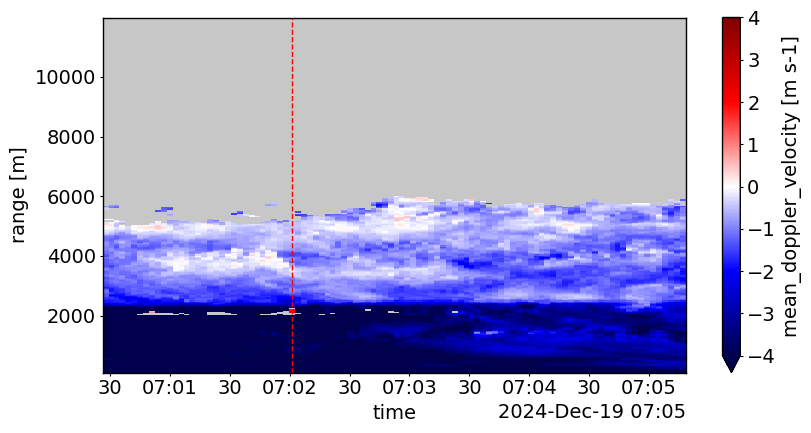

/var/folders/mn/f1v13wcs3ssgpznjftw2w6w00000gn/T/ipykernel_55042/397156273.py:58: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(dop_vel.values, range_, sds["sze_dBZ"].sel(velocity=dop_vel.velocity).values,
/var/folders/mn/f1v13wcs3ssgpznjftw2w6w00000gn/T/ipykernel_55042/397156273.py:58: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(dop_vel.values, range_, sds["sze_dBZ"].sel(velocity=dop_vel.velocity).values,
/var/folders/mn/f1v13wcs3ssgpznjftw2w6w00000gn/T/ipykernel_55042/397156273.py:58: UserWarning: The input coordinates to pcolormesh are int

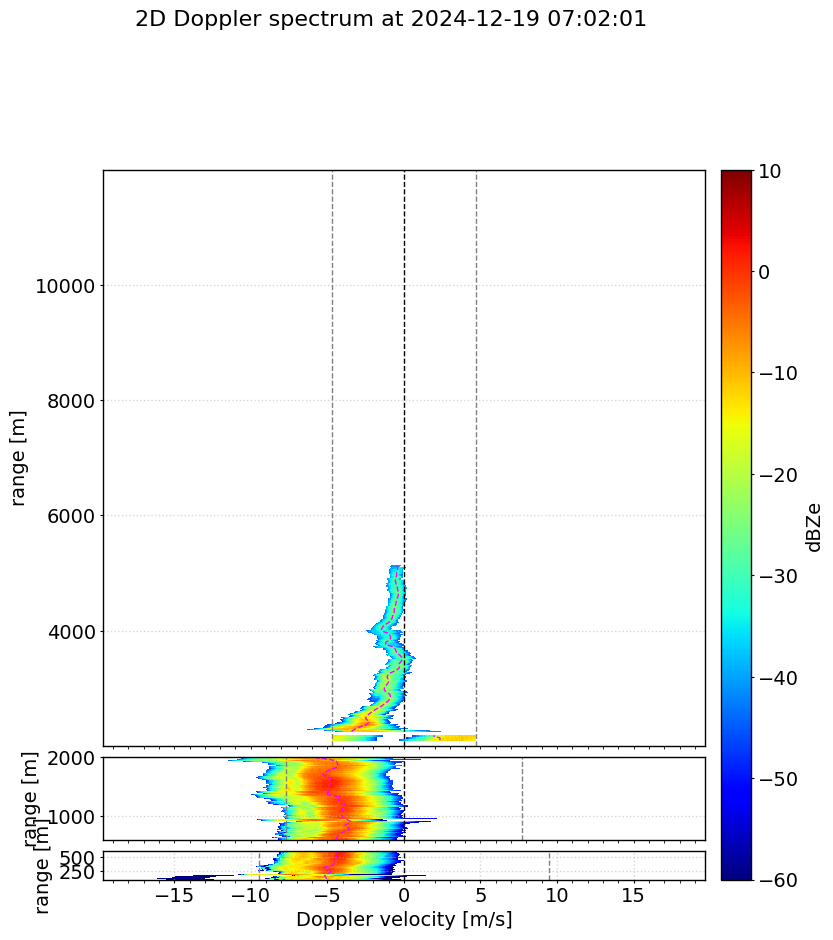

In [41]:
target_time = ds.time[32].values

# Plot the vertical line at the target time
plt.figure(figsize=(9, 5))
ds.vm.T.plot(cmap='seismic', vmin=-4, vmax=4)
plt.axvline(x=target_time, color='r', linestyle='--')
plt.show()

fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(ds.no_chirp_seq.values.item(), 2, 
                      height_ratios=list(chirp_info["height_ratio"].values())[::-1], 
                      width_ratios=[1, 0.05],
                      wspace=0.05, 
                      hspace=0.05)

sMinVel_target = ds.MinVel.sel(time=target_time)
new_nqv = np.max( np.abs(sMinVel_target) )
for i, chirp_ in enumerate(ds["number.chirp.sequences"].values):
    ax = fig.add_subplot(gs[ds.no_chirp_seq.values.item() - i - 1, 0])
    sds = ds.sel(range=ds["chirp_mask"].values == chirp_, time=target_time)
    sMinVel = ds.MinVel.sel(range=ds["chirp_mask"].values == chirp_, time=target_time)
    # mask_dealiasing = np.isnan(sMinVel.values)
    # dop_vel = np.repeat(dop_shift[np.newaxis,:], sMinVel.values.shape[0], axis=0) + sMinVel.values[:, np.newaxis]
    dop_vel = (sMinVel - sds.chirp_vel.sel({"number.chirp.sequences": chirp_})[0]).fillna(0)\
        + sds.chirp_vel.sel({"number.chirp.sequences": chirp_})
    
    dop_vel = dop_vel.dropna("velocity")
    
    # sds = sds.assign_coords({"true_chirp_vel": (("range", "velocity"), dop_vel.values)})
    # dop_vel = dop_vel.dropna(dim='velocity', how='all')
    # dop_vel = sds.chirp_vel.sel({"number.chirp.sequences": chirp_}).dropna("velocity")
    
    # # MAke the plot if the Doppler velocity is not empty
    # if dop_vel.size != 0:
    #     x0 = dop_vel.values[0, 0]
    #     x1 = dop_vel.values[0, -1]
    #     y0 = dop_vel.range.values[0]
    #     y1 = dop_vel.range.values[-1]
    # else:
    #     x0 = -new_nqv
    #     x1 = new_nqv
    #     y0 = sds.range.min()
    #     y1 = sds.range.max()
    # im = ax.imshow(sds["sze_dBZ"].values, 
    #             aspect="auto",
    #             extent=[x0, x1, y0, y1],
    #             #    extent=[np.nanmin(dop_vel[0,:]), np.nanmax(dop_vel[0,:]), sds.range[0], sds.range[-1]],
    #             cmap="jet",
    #             origin="lower",
    #             vmin=-60,
    #             vmax=10)
    
    # create a new range, repeteing the column to have the same dimention as the Doppler velocity:
    range_ = np.repeat(sds.range.values[:, np.newaxis], dop_vel.shape[1], axis=1)
    # get sze_dBz values for the same index as clean Doppler velocity
    # sds = sds.sel(velocity=dop_vel.velocity)

    im = ax.pcolormesh(dop_vel.values, range_, sds["sze_dBZ"].sel(velocity=dop_vel.velocity).values,
                    cmap="jet",
                    vmin=-60,
                    vmax=10)
    ax.plot(sds.vm.values, sds.vm.range.values, color="magenta", linestyle="--")
    # ax.plot(sds.MinVel.values, sds.MinVel.range.values, color="green", linestyle="--")

    ax.axvline(0, color="black", linestyle="--")
    ax.axvline(-sds.nqv.sel({"number.chirp.sequences": chirp_}).values.item(), color="gray", linestyle="--")
    ax.axvline(sds.nqv.sel({"number.chirp.sequences": chirp_}).values.item(), color="gray", linestyle="--")
    ax.set_xlim(-new_nqv, new_nqv)
    # ax.set_ylim(y0, y1)
    ax.set_ylabel(f"{sds.sze.range.long_name} [{sds.sze.range.units}]")
    ax.grid()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))  # Add more subticks
    # let the background white:
    ax.set_facecolor("white")
    if chirp_ == 1:
        ax.set_xlabel(f"Doppler velocity [{sds.chirp_vel.attrs['units']}]")
        ax.xaxis.set_ticks_position('bottom')
    else:
        ax.set_xticks([])
# add a sup title
fig.suptitle(f"2D Doppler spectrum at {pd.to_datetime(target_time).strftime('%Y-%m-%d %H:%M:%S')}", fontsize=16)
    
cax = fig.add_subplot(gs[:, 1])
cbar = fig.colorbar(im, cax=cax, orientation="vertical", label=sds["sze_dBZ"].attrs["units"])

plt.show()

In [33]:
ds.MinVel

<xarray.DataArray 'MinVel' (time: 1195, range: 424)>
[506680 values with dtype=float32]
Coordinates:
  * range    (range) float32 108.5 135.6 162.8 ... 1.487e+04 1.492e+04 1.497e+04
  * time     (time) datetime64[ns] 2021-06-01T12:00:01 ... 2021-06-01T12:59:58
Attributes:
    standard_name:  Minimum velocity in velocity array
    comment:        If dealising was applied the array indicates the velocity...
    units:          m/s